Лаба будет обучить мнист. MNIST это набор картинок размер которых 1x28x28. \
Берите датасет в котором пиксель может быть вещественным числом от 0 до 1. \
Просто там есть датасет у которого значение пикселя либо 0 либо 1, его скипаем.\
Это задача классификации, на каждой картинке написана цифра, и нужно предктнуть что это за цифра

Все что прошли на лабе должно хватить чтобы решить эту лабу.\
Вещи с которыми столкнетесь по мере решения лабы
1) написать свой датасет(класс) и даталаудер \
2) написать архитектуру MLP+классификатор \
3) использовать либо SGD либо Adam в качестве оптимизатора \
4) использовать CrossEntropyLoss в качестве лоссфункции \
5) использовать ReLU в качестве функции активации \
6) переводить модель на cuda, переводить номер класса в one hot вектор, использовать argmax для обратного преобразования \

Напомню, слой классификации это обычный линейный слой, у которого функция активации Softmax(но это не обязательно, нужно только для того чтобы увидеть именно вероятности)

In [1]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split

from tqdm import tqdm

In [2]:
class MyMLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_1 = nn.Linear(28 * 28, 100)
    self.activation = nn.ReLU()
    self.linear_2 = nn.Linear(100, 150)
    self.linear_3 = nn.Linear(150, 10)
    self.softmax = nn.Softmax()

  def forward(self, x):
    x = x.view(-1, 28 * 28)
    x = self.linear_1(x)
    x = self.activation(x)
    x = self.linear_2(x)
    x = self.activation(x)
    x = self.linear_3(x)
    #x = self.softmax(x)
    return x

In [3]:
class MyMNISTDataset(torch.utils.data.Dataset):
  def __init__(self, images, labels):
    self.images = images
    self.labels = labels

  def __len__(self):
    return len(self.images)

  def __getitem__(self, index):
    return (self.images[index], self.labels[index])


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    ])

train_set = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
valid_set = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 7.03MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [6]:
train_set.data.shape

torch.Size([60000, 28, 28])

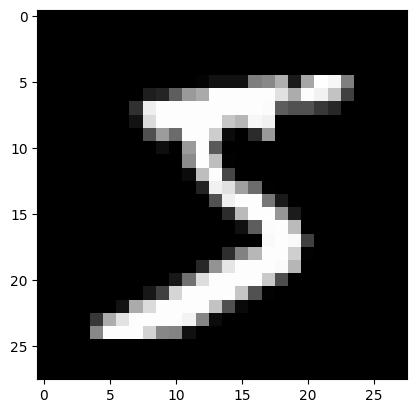

In [7]:
import matplotlib.pyplot as plt
plt.imshow(train_set.data[0], cmap="gray")

In [8]:
train_mnist_dataset = MyMNISTDataset(train_set.data, train_set.targets)
valid_mnist_dataset = MyMNISTDataset(valid_set.data, valid_set.targets)

In [9]:
train_data = DataLoader(train_mnist_dataset, batch_size=16, shuffle=True)
valid_data = DataLoader(valid_mnist_dataset, batch_size=16, shuffle=True)

In [48]:
train_loss_list = []
valid_loss_list = []
train_acc_list = []
valid_acc_list = []

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MyMLP().to(device)
optim = torch.optim.SGD(model.parameters(), lr=3e-4)
loss_fn = torch.nn.CrossEntropyLoss()
device

device(type='cuda')

In [50]:
for epoch in range(30):
  model.train()
  train_loss_mean = 0
  valid_loss_mean = 0
  train_acc_mean = 0
  valid_acc_mean = 0
  for data, target in (pbar := tqdm(train_data)):

    optim.zero_grad()

    data = data.to(device)
    target = target.to(device)

    out = model(data.float())
    train_acc = float((out.argmax(dim=1) == target).sum()/16)
    train_acc_mean += train_acc

    out_one_hot = (out.argmax(dim=1))

    out_one_hot = F.one_hot(out_one_hot, num_classes=10).float()
    target = F.one_hot(target, num_classes=10).float()

    # target_arg = target.argmax(dim=1)
    # out_arg = out_one_hot.argmax(dim=1)

    loss = loss_fn(out, target.argmax(dim=1))

    loss.backward()
    train_loss_mean += loss.item()

    optim.step()

    pbar.set_postfix({"Loss": loss.item(), "Accuracy": train_acc}, refresh=True)

  for data, target in (pbar := tqdm(valid_data)):
    model.eval()
    with torch.no_grad():
      data = data.to(device)
      target = target.to(device)

      out = model(data.float())

      valid_acc = float((out.argmax(dim=1) == target).sum()/16)
      valid_acc_mean += valid_acc

      target = F.one_hot(target, num_classes=10).float()

      loss = loss_fn(out, target.argmax(dim=1))
      valid_loss_mean += loss.item()

      pbar.set_postfix({"Loss": loss.item(), "Accuracy": valid_acc}, refresh=True)

  train_loss_list.append(train_loss_mean/len(train_data))
  valid_loss_list.append(valid_loss_mean/len(valid_data))
  train_acc_list.append(train_acc_mean/len(train_data))
  valid_acc_list.append(valid_acc_mean/len(valid_data))

100%|██████████| 625/625 [00:01<00:00, 434.53it/s, Loss=0.0041, Accuracy=1]


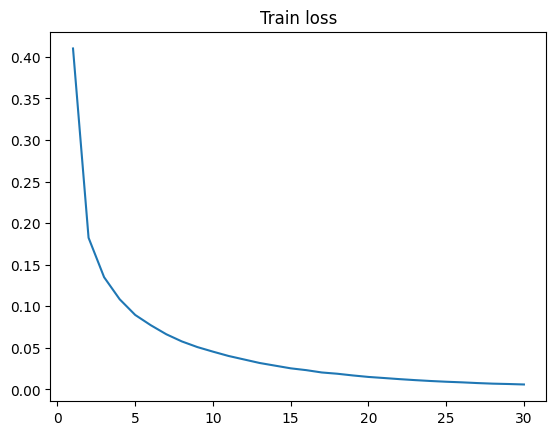

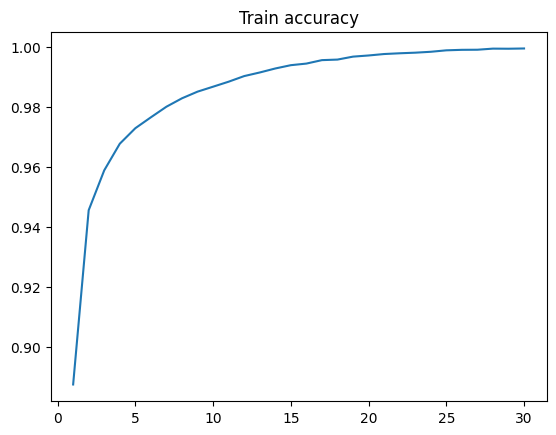

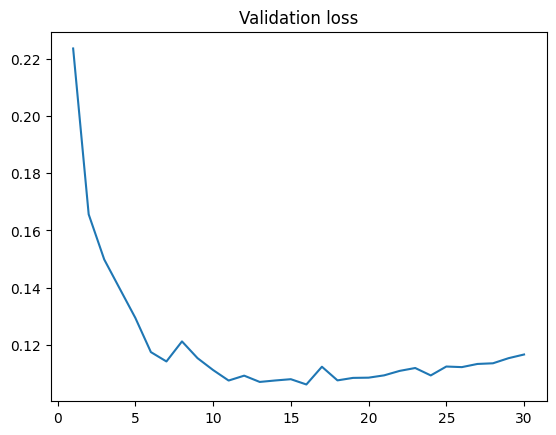

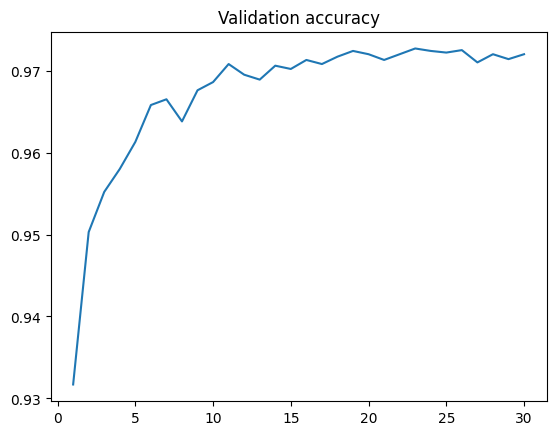

In [51]:
import matplotlib.pyplot as plt

plt.plot(range(1, 31), train_loss_list)
plt.title("Train loss")
plt.show()

plt.plot(range(1, 31), train_acc_list)
plt.title("Train accuracy")
plt.show()

plt.plot(range(1, 31), valid_loss_list)
plt.title("Validation loss")
plt.show()

plt.plot(range(1, 31), valid_acc_list)
plt.title("Validation accuracy")
plt.show()

In [36]:
loss = nn.CrossEntropyLoss()
input = torch.randn(3, 5, requires_grad=True)
target = torch.empty(3, dtype=torch.long).random_(5)
output = loss(input, target)
print(input)
print()
print(target)
print()


tensor([[ 1.3220, -0.6173,  0.2819,  1.8878, -1.3807],
        [-0.8876,  0.1760, -1.1230, -1.2038,  0.0394],
        [-1.4380,  0.7219,  1.4647,  0.4866, -1.2093]], requires_grad=True)

tensor([1, 4, 4])
